In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target

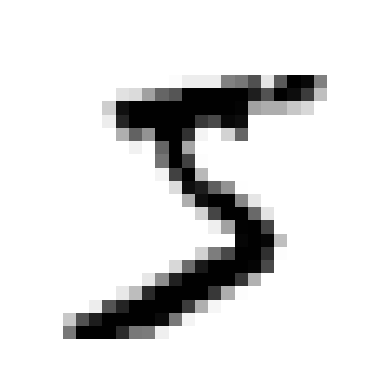

In [4]:
def plot_num(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis('off')
    
num = X[0]

plot_num(num)

In [5]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [26]:
def one_pixel_shift(image, direction):
    if(direction==0 or direction=='right'):
        img_extra = np.insert(image.copy(), 0, 0)
        img_shifted = np.delete(img_extra, 783)
        return img_shifted
    
    if(direction==1 or direction=='left'):
        img_extra = np.delete(image.copy(), 0)
        img_shifted = np.append(img_extra, 0)
        return img_shifted
    
    if(direction==2 or direction=='up'):
        one_layer_plus = np.zeros(28)
        one_layer_minus = np.array(list(range(0,28)))

        img_extra = np.delete(image.copy(), one_layer_minus)
        img_shifted = np.append(img_extra, one_layer_plus)
        return img_shifted

    if(direction==3 or direction=='down'):
        one_layer_plus = np.zeros(28)
        one_layer_minus = 784 - np.array(list( range(0,28)))

        img_extra = np.insert(image.copy(), 0,  one_layer_plus)
        img_shifted = np.delete(img_extra, one_layer_minus)
        return img_shifted

In [28]:
X_train_expanded = []
y_train_expanded = []

for i in range(0, len(X_train)):
    X_train_expanded.append(X_train[i])
    y_train_expanded.append(y_train[i])
    for j in range(0, 4):
        X_train_expanded.append(one_pixel_shift(X_train[i], j))
        y_train_expanded.append(y_train[i])
            
    
X_train_expanded = np.array(X_train_expanded)
y_train_expanded = np.array(y_train_expanded)

In [ ]:
#shuffling values
indices = np.arange(len(X_train_expanded))
np.random.seed(52)
np.random.shuffle(indices)

# перемешиваем по этому порядку
X_expanded = X_train_expanded[indices]
y_expanded = y_train_expanded[indices]

In [33]:
y_expanded[:100]

array(['3', '0', '1', '6', '6', '8', '9', '6', '7', '5', '9', '2', '2',
       '2', '4', '2', '1', '6', '3', '3', '3', '6', '3', '6', '3', '4',
       '7', '1', '0', '4', '7', '7', '1', '6', '2', '5', '7', '2', '8',
       '5', '1', '6', '3', '8', '0', '4', '0', '8', '2', '9', '0', '3',
       '0', '4', '5', '8', '0', '3', '4', '2', '9', '1', '1', '1', '2',
       '9', '3', '7', '7', '1', '1', '1', '0', '1', '1', '5', '7', '5',
       '8', '9', '0', '9', '5', '2', '0', '8', '0', '9', '1', '6', '9',
       '4', '3', '1', '1', '2', '3', '9', '4', '7'], dtype='<U1')

In [34]:
len(X_expanded)

300000

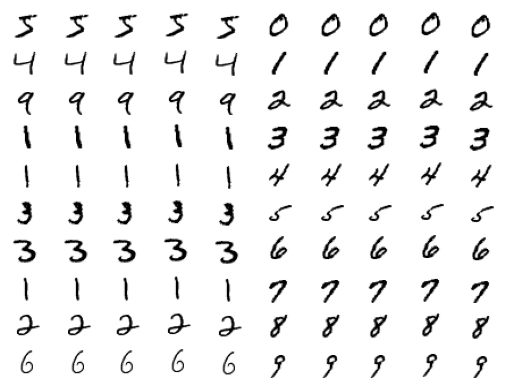

In [35]:
for i in range(1, 101):
        plt.subplot(10,10, i)
        plt.axis('off')
        plt.imshow(X_train_expanded[i-1].reshape(28, 28), cmap='binary')

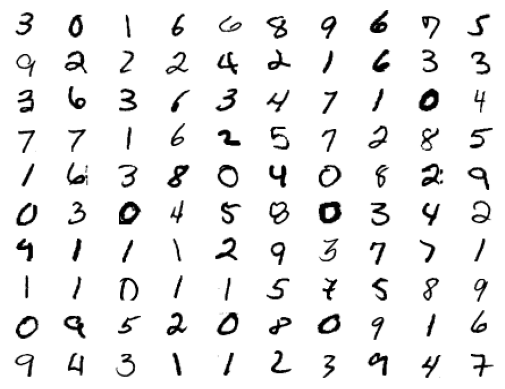

In [43]:
for i in range(1, 101):
        plt.subplot(10,10, i)
        plt.axis('off')
        plt.imshow(X_expanded[i-1].reshape(28, 28), cmap='binary')

In [44]:
from sklearn.neighbors import KNeighborsClassifier

kn_cls = KNeighborsClassifier(n_neighbors=3, weights='distance') #best among grid_search parametres

kn_cls.fit(X_expanded, y_expanded)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
from sklearn.model_selection import cross_val_score

cross_val_score(kn_cls, X_expanded, y_expanded, scoring='accuracy', cv=3)

array([0.98349, 0.98261, 0.98252])

In [47]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(kn_cls, X_expanded, y_expanded, cv=3)

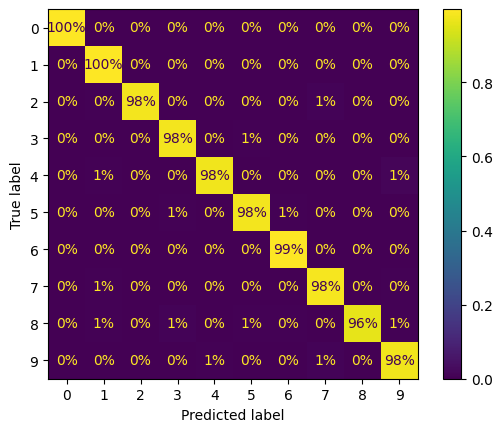

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_expanded, y_pred, normalize='true', values_format=".0%")

In [130]:
def inverse_colors(img):
    img_arr = plt.imread(img, format='')[:,:,2]
    img_arr = (img_arr.reshape(1, 784))
    img_arr = 255 - img_arr
    img_arr[img_arr < 60] = 0
    return img_arr

#img_arr

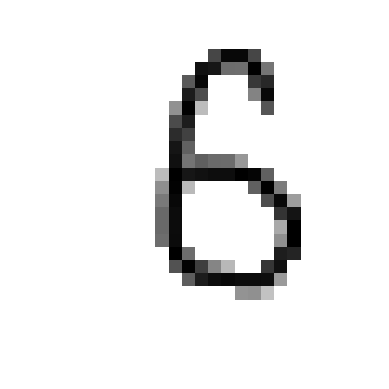

In [133]:
img_arr = inverse_colors('zhopa.jpg')
plot_num(img_arr)

In [134]:
kn_cls.predict(img_arr)[0]

np.str_('6')

In [125]:
final_predictions = kn_cls.predict(X_test)

accuracy = np.mean(final_predictions == y_test)
print(accuracy)

0.9763
